In [2]:
#!pip install --force-reinstall scikit-learn
!pip show scikit-learn

Name: scikit-learn
Version: 1.8.0
Summary: A set of python modules for machine learning and data mining
Home-page: https://scikit-learn.org
Author: 
Author-email: 
License: 
Location: /usr/local/lib/python3.12/dist-packages
Requires: joblib, numpy, scipy, threadpoolctl
Required-by: esda, fastai, hdbscan, imbalanced-learn, libpysal, librosa, mapclassify, mlxtend, pynndescent, pysal, segregation, sentence-transformers, shap, sklearn-compat, sklearn-pandas, spopt, spreg, tsfresh, umap-learn, yellowbrick


In [3]:
import pandas as pd

# Load the CSV file into a DataFrame
file_path = '/content/combined_output.csv'
df = pd.read_csv(file_path)

# Display the first 5 rows of the DataFrame
print("First 5 rows of the DataFrame:")
display(df.head())

# Display basic information about the DataFrame, including data types and non-null values
print("\nDataFrame Info:")
df.info()

First 5 rows of the DataFrame:


,resp_pkts,service,orig_ip_bytes,local_resp,missed_bytes,protocol,duration,conn_state,dest_ip,orig_pkts,...,orig_bytes,local_orig,datetime,history,resp_bytes,uid,src_port,ts,src_ip,mitre_attack_tactics
0,0,dns,138,False,0,udp,0.000131,S0,8.8.8.8,2,...,82.0,False,2022-01-12T12:03:40.587Z,D,0.0,CtpG8TClHAYO9wT2a,40990,1.642011e+09,143.88.11.10,none
1,0,dns,158,True,0,udp,0.000014,S0,10.0.10.1,2,...,102.0,False,2022-01-15T04:28:44.680Z,D,0.0,CDeIXt3htmSKYrLLx9,33719,1.642243e+09,143.88.255.10,none
2,0,dns,138,False,0,udp,0.000177,S0,8.8.4.4,2,...,82.0,False,2022-01-11T09:48:09.515Z,D,0.0,CtvUql2cmLjStb42b3,34632,1.641916e+09,143.88.11.10,none
3,0,dns,158,True,0,udp,0.000002,S0,10.0.10.1,2,...,102.0,False,2022-01-10T06:37:18.036Z,D,0.0,CEuDFx4W9g1GbZ1yi3,56303,1.641818e+09,143.88.255.10,none
4,0,dns,158,True,0,udp,0.000016,S0,10.0.10.1,2,...,102.0,False,2022-01-09T05:34:52.970Z,D,0.0,CVnwor3MyNzbjLnRSh,34532,1.641728e+09,143.88.255.10,none



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79263 entries, 0 to 79262
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   resp_pkts             79263 non-null  int64  
 1   service               75438 non-null  object 
 2   orig_ip_bytes         79263 non-null  int64  
 3   local_resp            79263 non-null  bool   
 4   missed_bytes          79263 non-null  int64  
 5   protocol              79263 non-null  object 
 6   duration              75278 non-null  float64
 7   conn_state            79263 non-null  object 
 8   dest_ip               79263 non-null  object 
 9   orig_pkts             79263 non-null  int64  
 10  community_id          79263 non-null  object 
 11  resp_ip_bytes         79263 non-null  int64  
 12  dest_port             79263 non-null  int64  
 13  orig_bytes            75278 non-null  float64
 14  local_orig            79263 non-null  bool   
 15  da

From the output above, we can see the columns available in your dataset. To proceed with detecting 'Reconnaissance attacks', we need to:

1.  **Identify a Target Variable**: There should be a column in your dataset that indicates whether a given log entry is a 'Reconnaissance attack' or not (e.g., 'Attack_Type', 'Label', or similar, with values like 'Reconnaissance' or 'Normal'). If such a column doesn't exist, you might need to label your data manually or define criteria to identify these attacks.
2.  **Feature Engineering**: Based on the nature of the data, we'll need to select relevant features that could help predict 'Reconnaissance attacks'. This might involve encoding categorical variables, handling missing values, or creating new features.

Please let me know which column represents the 'attack type' or 'label' in your dataset, and I can help you prepare the data and build the Decision Tree model.

### 1. Inspect Target Variable: `mitre_attack_tactics`

In [4]:
print("Unique values in 'mitre_attack_tactics' column:")
print(df['mitre_attack_tactics'].value_counts())

Unique values in 'mitre_attack_tactics' column:
mitre_attack_tactics
none              61199
Reconnaissance    18064
Name: count, dtype: int64


### 2. Data Cleaning: Handle Missing Values
I will drop rows where key numerical features or categorical features used for classification have missing values, to ensure the model receives complete data.

In [5]:
# Drop rows with any missing values in critical columns
df_cleaned = df.dropna(subset=['duration', 'orig_bytes', 'resp_bytes', 'service', 'history']).copy()

print(f"Original DataFrame shape: {df.shape}")
print(f"Cleaned DataFrame shape: {df_cleaned.shape}")
print("\nMissing values after cleaning:")
print(df_cleaned.isnull().sum()[df_cleaned.isnull().sum() > 0])

Original DataFrame shape: (79263, 23)
Cleaned DataFrame shape: (72522, 23)

Missing values after cleaning:
Series([], dtype: int64)


### 3. Feature Selection and 4. Target Variable Creation

I'll select a set of numerical and categorical features for the model. The `mitre_attack_tactics` column will be used to create a binary target variable `is_reconnaissance`.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Columns to be explicitly excluded from training
excluded_columns = [
    "dest_ip",
    "src_ip",
    "uid",
    "community_id",
    "datetime",
    "ts"
]

# Create a copy of the cleaned DataFrame and drop the excluded columns from it
df_processed = df_cleaned.drop(columns=excluded_columns, errors='ignore').copy()

# Define features (X) and target (y)
numerical_features = [
    'resp_pkts', 'orig_ip_bytes', 'missed_bytes', 'duration',
    'orig_pkts', 'resp_ip_bytes', 'dest_port', 'orig_bytes', 'resp_bytes', 'src_port'
]
categorical_features = [
    'service', 'protocol', 'conn_state', 'local_resp', 'local_orig'
]

# Combine numerical and categorical features
features = numerical_features + categorical_features

# Ensure all selected features are present in df_processed
missing_features = [f for f in features if f not in df_processed.columns]
if missing_features:
    raise ValueError(f"The following features are missing from df_processed: {missing_features}")

X = df_processed[features]

# --- Feature Engineering: Create new features ---
# Total packets and bytes
X['total_pkts'] = X['orig_pkts'] + X['resp_pkts']
X['total_bytes'] = X['orig_bytes'] + X['resp_bytes']

# Packet and byte ratios (handling division by zero)
X['pkt_ratio'] = X['resp_pkts'] / X['total_pkts'].replace(0, np.nan)
X['byte_ratio'] = X['resp_bytes'] / X['total_bytes'].replace(0, np.nan)
X[['pkt_ratio', 'byte_ratio']] = X[['pkt_ratio', 'byte_ratio']].fillna(0) # Fill NaN from 0/0 with 0

# Packet and byte rates (handling division by zero and infinite values)
X['pkt_rate'] = X['total_pkts'] / X['duration'].replace(0, np.nan)
X['byte_rate'] = X['total_bytes'] / X['duration'].replace(0, np.nan)
# Fill NaN and inf values that arise from division by zero duration with 0
X[['pkt_rate', 'byte_rate']] = X[['pkt_rate', 'byte_rate']].replace([np.inf, -np.inf], 0).fillna(0)
# --- End Feature Engineering ---

# Create the target variable: 1 if 'Reconnaissance', 0 otherwise
y = (df_cleaned['mitre_attack_tactics'] == 'Reconnaissance').astype(int)

print("Features selected:", X.columns.tolist())
print("Target variable value counts:\n", y.value_counts())

Features selected: ['resp_pkts', 'orig_ip_bytes', 'missed_bytes', 'duration', 'orig_pkts', 'resp_ip_bytes', 'dest_port', 'orig_bytes', 'resp_bytes', 'src_port', 'service', 'protocol', 'conn_state', 'local_resp', 'local_orig', 'total_pkts', 'total_bytes', 'pkt_ratio', 'byte_ratio', 'pkt_rate', 'byte_rate']
Target variable value counts:
 mitre_attack_tactics
0    58407
1    14115
Name: count, dtype: int64


/tmp/ipykernel_33247/2895677865.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['total_pkts'] = X['orig_pkts'] + X['resp_pkts']


### 5. Categorical Feature Encoding

One-hot encode the selected categorical features. This converts them into a numerical format suitable for the Decision Tree.

In [7]:
X = pd.get_dummies(X, columns=categorical_features, drop_first=True)

print("Shape of features after one-hot encoding:", X.shape)
print("First 5 rows of features after encoding:")
display(X.head())

Shape of features after one-hot encoding: (72522, 23)
First 5 rows of features after encoding:


,resp_pkts,orig_ip_bytes,missed_bytes,duration,orig_pkts,resp_ip_bytes,dest_port,orig_bytes,resp_bytes,src_port,...,byte_ratio,pkt_rate,byte_rate,service_dns,service_ntp,protocol_udp,conn_state_SF,conn_state_SHR,local_resp_True,local_orig_True
0,0,138,0,0.000131,2,0,53,82.0,0.0,40990,...,0.0,1.525201e+04,6.253326e+05,True,False,True,False,False,False,False
1,0,158,0,0.000014,2,0,53,102.0,0.0,33719,...,0.0,1.421798e+05,7.251170e+06,True,False,True,False,False,True,False
2,0,138,0,0.000177,2,0,53,82.0,0.0,34632,...,0.0,1.129019e+04,4.628976e+05,True,False,True,False,False,False,False
3,0,158,0,0.000002,2,0,53,102.0,0.0,56303,...,0.0,1.048576e+06,5.347738e+07,True,False,True,False,False,True,False
4,0,158,0,0.000016,2,0,53,102.0,0.0,34532,...,0.0,1.252031e+05,6.385358e+06,True,False,True,False,False,True,False


### 6. Data Splitting

Split the data into training and testing sets to evaluate the model's performance on unseen data.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (50765, 23)
X_test shape: (21757, 23)
y_train shape: (50765,)
y_test shape: (21757,)


### 7. Model Training: Decision Tree Classifier

Now, let's train a Decision Tree Classifier.

In [9]:
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)

print("Decision Tree Classifier trained successfully.")

Decision Tree Classifier trained successfully.


### 8. Model Evaluation

Finally, evaluate the performance of the trained Decision Tree model on the test set.

In [10]:
y_train_pred = dt_classifier.predict(X_train)
y_test_pred = dt_classifier.predict(X_test)

print("Training Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("\nConfusion Matrix (Test Set):\n", confusion_matrix(y_test, y_test_pred))
print("\nClassification Report (Test Set):\n", classification_report(y_test, y_test_pred))

Training Accuracy: 1.0
Test Accuracy: 0.9955416647515742

Confusion Matrix (Test Set):
 [[17429    93]
 [    4  4231]]

Classification Report (Test Set):
               precision    recall  f1-score   support

           0       1.00      0.99      1.00     17522
           1       0.98      1.00      0.99      4235

    accuracy                           1.00     21757
   macro avg       0.99      1.00      0.99     21757
weighted avg       1.00      1.00      1.00     21757



### Features Used in the Decision Tree Model

In [14]:
print(X.columns.tolist())

['resp_pkts', 'orig_ip_bytes', 'missed_bytes', 'duration', 'orig_pkts', 'resp_ip_bytes', 'dest_port', 'orig_bytes', 'resp_bytes', 'src_port', 'total_pkts', 'total_bytes', 'pkt_ratio', 'byte_ratio', 'pkt_rate', 'byte_rate', 'service_dns', 'service_ntp', 'protocol_udp', 'conn_state_SF', 'conn_state_SHR', 'local_resp_True', 'local_orig_True']


### 9. Visualize the Decision Tree

Let's visualize the trained Decision Tree to understand its structure and decision-making process. Due to the perfect accuracy, the tree might be very simple or perfectly split the data based on the features.

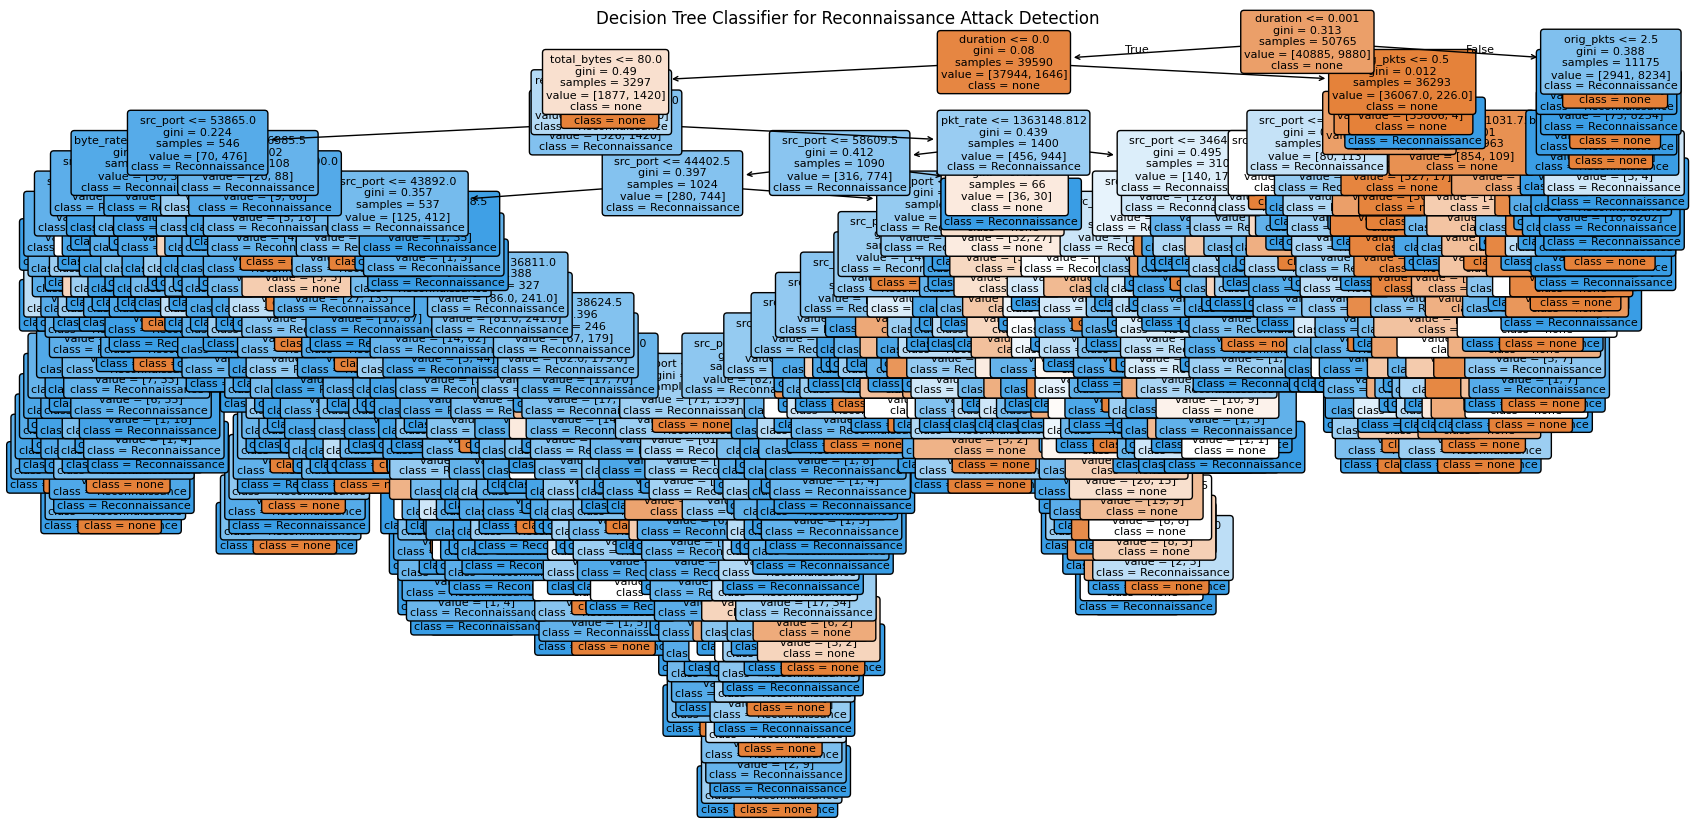

In [11]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10)) # Adjust figure size for better readability
plot_tree(dt_classifier,
          feature_names=X.columns.tolist(),
          class_names=['none', 'Reconnaissance'], # Class names for target variable
          filled=True,
          rounded=True,
          fontsize=8)
plt.title("Decision Tree Classifier for Reconnaissance Attack Detection")
plt.show()

In [12]:
import joblib
from google.colab import files

# Define the path where the model will be saved
MODEL_PATH = 'decision_tree_model.joblib'

# Save the trained model to a joblib file
joblib.dump(dt_classifier, MODEL_PATH)
print(f"Model saved to {MODEL_PATH}")

try:
    # Download the saved model file
    files.download(MODEL_PATH)
    print(f"Downloading {MODEL_PATH}...")
except FileNotFoundError:
    print(f"Error: The file {MODEL_PATH} was not found. Please ensure the model has been saved.")
except Exception as e:
    print(f"An error occurred during download: {e}")

Model saved to decision_tree_model.joblib


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>